In [1]:
def preprocess_nslkdd_presplit(train_path, test_path):
    # 1. Hardcoded columns
    columns = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
               'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
               'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
               'num_shells','num_access_files','num_outbound_cmds','is_host_login',
               'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
               'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
               'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
               'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
               'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
               'dst_host_rerror_rate','dst_host_srv_rerror_rate','attack','level']

    print(f"Loading Train file: {train_path}")
    train_df = pd.read_csv(train_path, names=columns, header=None, low_memory=False)
    train_df['is_train'] = 1

    print(f"Loading Test file: {test_path}")
    test_df = pd.read_csv(test_path, names=columns, header=None, low_memory=False)
    test_df['is_train'] = 0

    # Combine temporarily for consistent One-Hot Encoding dimensions
    data = pd.concat([train_df, test_df], ignore_index=True)

    # 2. Extract Level and Drop Zero-Variance Features
    levels_all = data['level'].values
    # Drop 'level' to prevent data leakage and 'num_outbound_cmds' because it is strictly zeros
    data = data.drop(columns=['level', 'num_outbound_cmds'], errors='ignore')

    # 3. Group Attack Categories
    dos_attacks = ['neptune', 'smurf', 'back', 'teardrop', 'pod', 'land', 'mailbomb', 'processtable', 'udpstorm', 'apache2', 'worm']
    probe_attacks = ['satan', 'ipsweep', 'portsweep', 'nmap', 'mscan', 'saint']
    r2l_attacks = ['guess_passwd', 'ftp_write', 'imap', 'phf', 'multihop', 'warezmaster', 'warezclient', 'spy', 'xlock', 'xsnoop', 'snmpguess', 'snmpgetattack', 'httptunnel', 'sendmail', 'named']
    u2r_attacks = ['buffer_overflow', 'rootkit', 'loadmodule', 'perl', 'sqlattack', 'xterm', 'ps']

    def map_attack(attack):
        if attack == 'normal': return 'Normal'
        if attack in dos_attacks: return 'DoS'
        if attack in probe_attacks: return 'Probe'
        if attack in r2l_attacks: return 'R2L'
        if attack in u2r_attacks: return 'U2R'
        return 'Other'

    data['attack'] = data['attack'].apply(map_attack)

    # 4. Prepare features and separate targets/tags
    y_raw = data['attack'].values
    is_train_mask = data['is_train'].values
    X_df = data.drop(columns=['attack', 'is_train'])

    # 5. Log Transformation for Highly Skewed Features
    skewed_cols = ['src_bytes', 'dst_bytes', 'duration']
    print("\nApplying Log1p transformations to highly skewed features...")
    for col in skewed_cols:
        if col in X_df.columns:
            # np.log1p applies log(1+x) to safely handle zeros
            X_df[col] = np.log1p(X_df[col].astype(float))

    # 6. One-Hot Encoding for Categorical Features
    cat_columns = ['protocol_type', 'service', 'flag']
    print("Applying One-Hot Encoding to categorical network protocols...")
    # pd.get_dummies converts string categories into separate binary columns
    X_df = pd.get_dummies(X_df, columns=cat_columns, drop_first=False)

    # Convert the entire dataframe to a float numpy array (handles the booleans from get_dummies)
    X_all = X_df.astype(float).fillna(0).to_numpy()
    X_all = np.clip(X_all, -1e6, 1e6)

    # Encode Target Labels (0 to 4)
    le_target = LabelEncoder()
    y_all = le_target.fit_transform(y_raw)

    # 7. SPLIT BACK APART USING THE TAG
    train_idx = (is_train_mask == 1)
    test_idx = (is_train_mask == 0)

    X_train_full = X_all[train_idx]
    y_train_full = y_all[train_idx]

    X_test_global = X_all[test_idx]
    y_test_global = y_all[test_idx]
    levels_test = levels_all[test_idx]

    output_dim = len(le_target.classes_)
    input_dim = X_train_full.shape[1]

    print(f"\n--- Attack Category Distribution (Test Set Only) ---")
    unique, counts = np.unique(y_raw[test_idx], return_counts=True)
    for u, c in zip(unique, counts): print(f"{u}: {c}")

    return X_train_full, y_train_full, X_test_global, y_test_global, levels_test, input_dim, output_dim, le_target.classes_

In [2]:
def evaluate_by_difficulty(y_true, y_pred, levels, class_names):
    print("\n" + "="*50)
    print("--- Evaluation by Difficulty Level ---")

    # Define the masks based on your rules
    masks = {
        'Hard': levels < 10,
        'Medium': (levels >= 10) & (levels < 18),
        'Easy': levels >= 18
    }

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes = axes.flatten()

    for i, (diff_name, mask) in enumerate(masks.items()):
        y_t = y_true[mask]
        y_p = y_pred[mask]

        if len(y_t) == 0:
            print(f"{diff_name}: No samples found in this difficulty range.")
            axes[i].axis('off')
            axes[i].set_title(f"{diff_name} (0 samples)")
            continue

        acc = accuracy_score(y_t, y_p)
        f1 = f1_score(y_t, y_p, average="weighted")

        print(f"[{diff_name}] (Samples: {len(y_t):>5}) | Accuracy = {acc:.4f} | F1-score = {f1:.4f}")

        # We explicitly pass labels=range(len(class_names)) to ensure the matrix
        # is always 5x5, even if a difficulty tier is missing a specific class
        sns.heatmap(
            confusion_matrix(y_t, y_p, labels=range(len(class_names))),
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[i],
            xticklabels=class_names,
            yticklabels=class_names
        )
        axes[i].set_title(f'{diff_name} Difficulty\n(Acc: {acc:.2f})')

    plt.tight_layout()
    plt.show()

In [3]:
!pip install tenseal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 41.7 MB/s eta 0:00:00


In [4]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import tenseal as ts
import gc

SEED = 42
BATCH_SIZE = 128
NUM_CLIENTS = 6
PUBLIC_DATA_RATIO = 0.05
VAL_SIZE = 0.1
ROUNDS = 5
LOCAL_EPOCHS = 3
TEMPERATURE = 3.0

torch.manual_seed(SEED)
np.random.seed(SEED)


In [5]:
# Look at your file explorer to ensure these exact file names match (add .txt if your system requires it)
TRAIN_FILE = r"/content/KDDTrain+.txt"
TEST_FILE = r"/content/KDDTest+.txt"

X_train_full, y_train_full, X_test_global, y_test_global, levels_test, INPUT_DIM, OUTPUT_DIM, class_names = preprocess_nslkdd_presplit(
    train_path=TRAIN_FILE,
    test_path=TEST_FILE
)

print(f"\nPreprocessing Complete. Input Dim: {INPUT_DIM}, Output Dim: {OUTPUT_DIM}")
print(f"Classes: {class_names}")


print("\nApplying Robust Scaling to handle dataset shift...")
scaler = RobustScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test_global = scaler.transform(X_test_global)

Loading Train file: /content/KDDTrain+.txt
Loading Test file: /content/KDDTest+.txt

Applying Log1p transformations to highly skewed features...
Applying One-Hot Encoding to categorical network protocols...

--- Attack Category Distribution (Test Set Only) ---
DoS: 7460
Normal: 9711
Probe: 2421
R2L: 2885
U2R: 67

Preprocessing Complete. Input Dim: 121, Output Dim: 5
Classes: ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']

Applying Robust Scaling to handle dataset shift...



 Client Data Allocation
Client 0: 10372 Train samples, 1153 Val samples
Client 1: 25982 Train samples, 2887 Val samples
Client 2: 16604 Train samples, 1845 Val samples
Client 3: 33754 Train samples, 3751 Val samples
Client 4: 14866 Train samples, 1652 Val samples
Client 5: 6127 Train samples, 681 Val samples

 Federated Learning Experiment
Clients: 6 | Rounds: 5 | Local Epochs: 3
Aggregation: weighted; Distillation temperature: 3.0
Privacy: CKKS homomorphic encryption (No Differential Privacy)

Round 1 Aggregation Weights: ['0.096', '0.241', '0.154', '0.313', '0.138', '0.057']
Round 1 Statistics
Client 0: [Train] Acc 0.9931 | [Val] Acc 0.9931
Client 1: [Train] Acc 0.9925 | [Val] Acc 0.9913
Client 2: [Train] Acc 0.9833 | [Val] Acc 0.9783
Client 3: [Train] Acc 0.9679 | [Val] Acc 0.9696
Client 4: [Train] Acc 0.9795 | [Val] Acc 0.9812
Client 5: [Train] Acc 0.9940 | [Val] Acc 0.9927

Round 2 Aggregation Weights: ['0.168', '0.168', '0.166', '0.164', '0.166', '0.168']
Round 2 Statistics
Clie

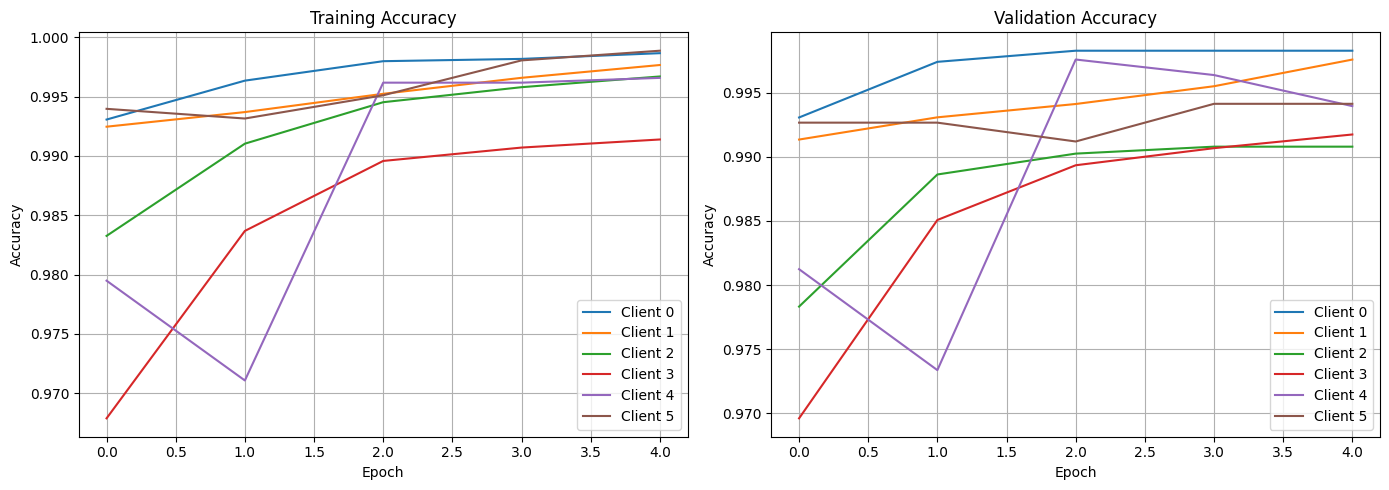

In [6]:
X_train_private, X_public, y_train_private, y_public = train_test_split(
    X_train_full, y_train_full, test_size=PUBLIC_DATA_RATIO, stratify=y_train_full, random_state=SEED
)
X_public_tensor = torch.tensor(X_public, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_global, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_global, dtype=torch.long)


def prepare_clients(X, y, num_clients=5, alpha=0.5):
    idx_by_label = {lbl: np.where(y == lbl)[0] for lbl in np.unique(y)}
    client_indices = {i: [] for i in range(num_clients)}
    for lbl, idxs in idx_by_label.items():
        np.random.shuffle(idxs)
        proportions = (np.random.dirichlet([alpha] * num_clients) * len(idxs)).astype(int)
        while proportions.sum() < len(idxs):
            proportions[np.argmax(proportions)] += 1
        start = 0
        for cid, cnt in enumerate(proportions):
            client_indices[cid].extend(idxs[start:start + cnt])
            start += cnt

    clients_data = []
    print("\n Client Data Allocation")
    for cid in range(num_clients):
        idxs = client_indices[cid]
        tr_idx, val_idx = train_test_split(idxs, test_size=VAL_SIZE, random_state=SEED)
        clients_data.append({
            'train': (torch.tensor(X[tr_idx], dtype=torch.float32), torch.tensor(y[tr_idx], dtype=torch.long)),
            'val': (torch.tensor(X[val_idx], dtype=torch.float32), torch.tensor(y[val_idx], dtype=torch.long)),
            'n_samples': len(tr_idx)
        })
        print(f"Client {cid}: {len(tr_idx)} Train samples, {len(val_idx)} Val samples")
    return clients_data

clients = prepare_clients(X_train_private, y_train_private, num_clients=NUM_CLIENTS)
TOTAL_TRAIN_SAMPLES = sum(c['n_samples'] for c in clients)

context = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=8192, coeff_mod_bit_sizes=[60, 40, 40, 60])
context.generate_galois_keys()
context.global_scale = 2**40


class Client0_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(INPUT_DIM, 512), nn.ReLU(), nn.Linear(512, OUTPUT_DIM))
    def forward(self, x):
        return self.net(x)


class Client1_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(INPUT_DIM, 256), nn.ReLU(), nn.Linear(256, OUTPUT_DIM))
    def forward(self, x):
        return self.net(x)


class Client2_ResMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(INPUT_DIM, 256)
        self.fc2 = nn.Linear(256, OUTPUT_DIM)
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class Client3_BiGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(1, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, OUTPUT_DIM)
    def forward(self, x):
        _, h = self.gru(x.unsqueeze(-1))
        return self.fc(torch.cat((h[-2], h[-1]), dim=1))


class Client4_TabAttention(nn.Module):
    def __init__(self, input_dim, output_dim, n_heads=4, embed_dim=32):
        super().__init__()
        self.feature_embed = nn.Linear(1, embed_dim)
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=n_heads, batch_first=True)
        self.ln = nn.LayerNorm(embed_dim)
        self.fc = nn.Sequential(
            nn.Linear(input_dim * embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.feature_embed(x)
        attn_out, _ = self.attention(x, x, x)
        x = self.ln(x + attn_out)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class Client5_CNN1D(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)

        self.flattened_size = 32 * INPUT_DIM

        self.fc1 = nn.Linear(self.flattened_size, 64)
        self.fc2 = nn.Linear(64, OUTPUT_DIM)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


models = {
    0: Client0_MLP(),
    1: Client1_MLP(),
    2: Client2_ResMLP(),
    3: Client3_BiGRU(),
    4: Client4_TabAttention(INPUT_DIM, OUTPUT_DIM),
    5: Client5_CNN1D()
}

optimizers = {cid: optim.Adam(models[cid].parameters(), lr=1e-3) for cid in range(NUM_CLIENTS)}

history_val = {cid: [] for cid in range(NUM_CLIENTS)}
history_train = {cid: [] for cid in range(NUM_CLIENTS)}
client_accuracies = {cid: 0.0 for cid in range(NUM_CLIENTS)}


def get_metrics(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X), dim=1).cpu().numpy()
        y_true = y.cpu().numpy()
    return accuracy_score(y_true, preds), f1_score(y_true, preds, average="weighted")


def local_train_and_encrypt(cid, aggregation_weight):
    model, opt = models[cid], optimizers[cid]
    Xc, yc = clients[cid]['train']

    class_counts = torch.bincount(yc, minlength=OUTPUT_DIM).float()
    total_samples = len(yc)
    class_weights = total_samples / (len(class_counts) * (class_counts + 10))
    class_weights = class_weights / class_weights.sum() * len(class_counts)
    class_weights = torch.clamp(class_weights, min=0.1, max=20.0)

    model.train()
    for epoch in range(LOCAL_EPOCHS):
        for i in range(0, len(Xc), BATCH_SIZE):
            opt.zero_grad()
            batch_X = Xc[i:i+BATCH_SIZE]
            batch_y = yc[i:i+BATCH_SIZE]

            outputs = model(batch_X)
            loss = F.cross_entropy(outputs, batch_y, weight=class_weights)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        avg_logits = model(X_public_tensor).mean(dim=0).cpu().numpy()

    return ts.ckks_vector(context, avg_logits * aggregation_weight)


def server_aggregate(encrypted_list):
    agg = encrypted_list[0]
    for i in range(1, len(encrypted_list)):
        agg += encrypted_list[i]
    return agg


def client_decryption_and_distill(cid, encrypted_global_vec):
    global_logits_plaintext = encrypted_global_vec.decrypt()
    target_logits = torch.tensor(global_logits_plaintext, dtype=torch.float32)

    model, opt = models[cid], optimizers[cid]
    model.train()
    opt.zero_grad()

    student_logits = model(X_public_tensor).mean(dim=0)
    T = TEMPERATURE

    loss = nn.KLDivLoss(reduction="batchmean")(
        F.log_softmax(student_logits.unsqueeze(0) / T, dim=1),
        F.softmax(target_logits.unsqueeze(0) / T, dim=1)
    ) * (T * T)

    loss.backward()
    opt.step()


print("\n Federated Learning Experiment")
print(f"Clients: {NUM_CLIENTS} | Rounds: {ROUNDS} | Local Epochs: {LOCAL_EPOCHS}")
print(f"Aggregation: weighted; Distillation temperature: {TEMPERATURE}")
print("Privacy: CKKS homomorphic encryption (No Differential Privacy)")


for r in range(ROUNDS):
    if r == 0:
        raw_weights = [clients[cid]['n_samples'] for cid in range(NUM_CLIENTS)]
    else:
        raw_weights = [client_accuracies[cid] + 1e-4 for cid in range(NUM_CLIENTS)]

    total_w = sum(raw_weights)
    norm_weights = [w / total_w for w in raw_weights]

    print(f"\nRound {r+1} Aggregation Weights: {[f'{w:.3f}' for w in norm_weights]}")

    ciphertexts = [local_train_and_encrypt(cid, norm_weights[cid]) for cid in range(NUM_CLIENTS)]
    encrypted_global = server_aggregate(ciphertexts)

    for cid in range(NUM_CLIENTS):
        client_decryption_and_distill(cid, encrypted_global)

    print(f"Round {r+1} Statistics")
    for cid in range(NUM_CLIENTS):
        t_acc, _ = get_metrics(models[cid], clients[cid]['train'][0], clients[cid]['train'][1])
        v_acc, _ = get_metrics(models[cid], clients[cid]['val'][0], clients[cid]['val'][1])
        history_train[cid].append(t_acc)
        history_val[cid].append(v_acc)
        client_accuracies[cid] = v_acc
        print(f"Client {cid}: [Train] Acc {t_acc:.4f} | [Val] Acc {v_acc:.4f}")


def ensemble_predict(models, X):
    logits_sum = None
    with torch.no_grad():
        for cid, model in models.items():
            model.eval()
            logits = model(X)
            if logits_sum is None:
                logits_sum = logits
            else:
                logits_sum += logits
        avg_logits = logits_sum / len(models)
        y_pred = torch.argmax(avg_logits, dim=1)
    return y_pred.cpu().numpy()


y_pred_ens = ensemble_predict(models, X_test_tensor)

ens_acc = accuracy_score(y_test_global, y_pred_ens)
ens_f1 = f1_score(y_test_global, y_pred_ens, average="weighted")

print("\n Global Ensemble Performance")
print(f"Ensemble Accuracy: {ens_acc:.4f}")
print(f"Ensemble F1-score: {ens_f1:.4f}")

plt.figure(figsize=(14, 5))

# Train Accuracy
plt.subplot(1, 2, 1)
for i in range(NUM_CLIENTS):
    plt.plot(history_train[i], label=f'Client {i}')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Validation Accuracy
plt.subplot(1, 2, 2)
for i in range(NUM_CLIENTS):
    plt.plot(history_val[i], label=f'Client {i}')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
print("\n Final Client-wise Performance ")
for cid in range(NUM_CLIENTS):
    acc, f1 = get_metrics(models[cid], X_test_tensor, y_test_tensor)
    print(f"Client {cid} ({models[cid].__class__.__name__}): Test Acc = {acc:.4f}, Test F1 = {f1:.4f}")


 Final Client-wise Performance 
Client 0 (Client0_MLP): Test Acc = 0.7709, Test F1 = 0.7364
Client 1 (Client1_MLP): Test Acc = 0.7813, Test F1 = 0.7444
Client 2 (Client2_ResMLP): Test Acc = 0.7618, Test F1 = 0.7331
Client 3 (Client3_BiGRU): Test Acc = 0.7186, Test F1 = 0.6699
Client 4 (Client4_TabAttention): Test Acc = 0.7480, Test F1 = 0.7077
Client 5 (Client5_CNN1D): Test Acc = 0.7603, Test F1 = 0.7487



--- Evaluation by Difficulty Level ---
[Hard] (Samples:  1228) | Accuracy = 0.0570 | F1-score = 0.0501
[Medium] (Samples:  5422) | Accuracy = 0.4524 | F1-score = 0.4643
[Easy] (Samples: 15894) | Accuracy = 0.9418 | F1-score = 0.9360


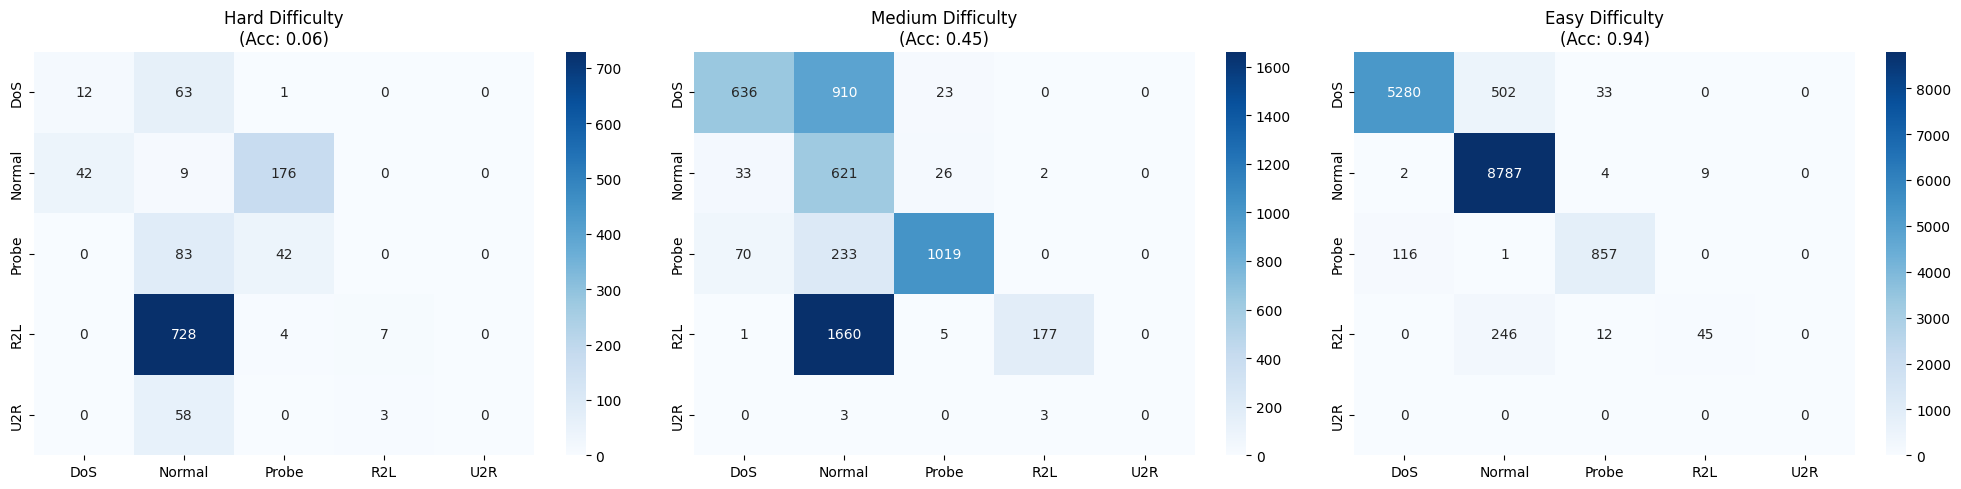

In [8]:
evaluate_by_difficulty(y_test_global, y_pred_ens, levels_test, class_names)

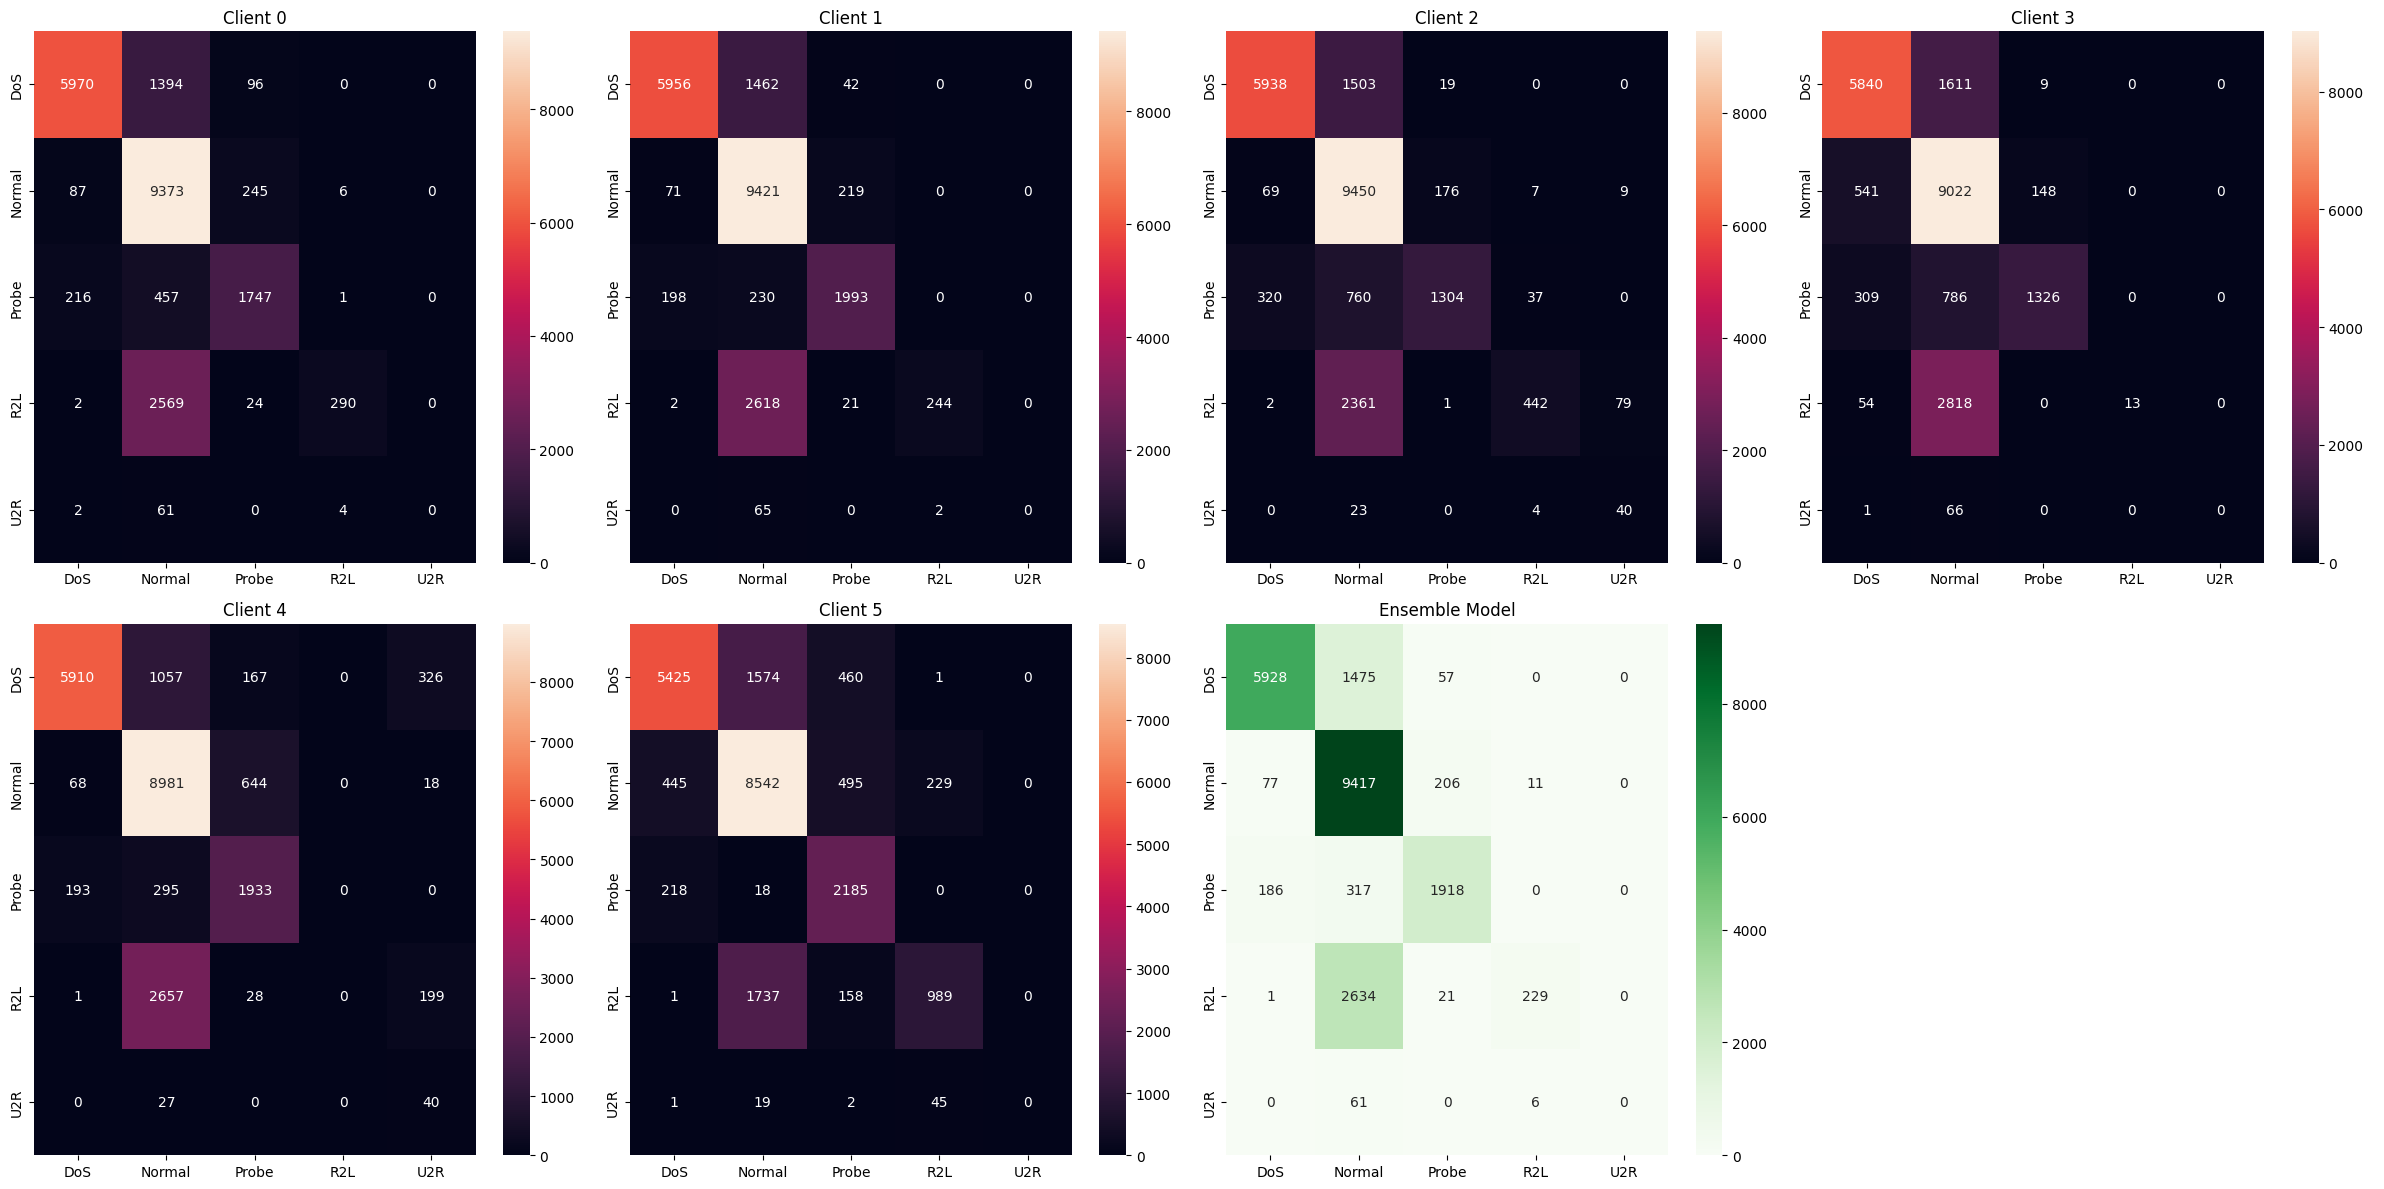

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

with torch.no_grad():
    for cid in range(NUM_CLIENTS):
        # The model now runs in "inference mode" (low memory)
        y_pred = torch.argmax(models[cid](X_test_tensor), dim=1).cpu().numpy()

        sns.heatmap(
            confusion_matrix(y_test_global, y_pred),
            annot=True,
            fmt='d',
            ax=axes[cid],
            xticklabels=class_names,
            yticklabels=class_names
        )
        axes[cid].set_title(f'Client {cid}')

sns.heatmap(
    confusion_matrix(y_test_global, y_pred_ens),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[6],
    xticklabels=class_names,
    yticklabels=class_names
)
axes[6].set_title('Ensemble Model')

axes[7].axis('off')

plt.tight_layout()
plt.show()